In [1]:
import pandas
print("hello")

hello


In [2]:
import pandas as pd
df =pd.read_csv("../data/sample_email.csv")
df.head()
# df.tail()

,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal


In [3]:
df.info

<bound method DataFrame.info of    id                  sender                                subject  \
0   1          hr@company.com             Offer Letter - Please Sign   
1   2    noreply@shopping.com               Big Billion Sale is Live   
2   3       alerts@mybank.com                  Unusual Login Attempt   
3   4     newsletter@blog.com                 Weekly Tech Newsletter   
4   5     friend123@gmail.com                   Coffee this weekend?   
5   6  spam@strange-domain.ru                  You won $1,000,000!!!   
6   7     manager@company.com                Project Update Required   
7   8        training@lms.com  Reminder: Complete Mandatory Training   

                                                body priority       label  
0  Dear Candidate, Congratulations! Please sign a...     high   important  
1  Flat 70% OFF on electronics. Limited period of...      low   promotion  
2  We detected a login attempt to your account fr...     high    security  
3  In this week

In [4]:
(df["label"] == "important").sum()


np.int64(1)

In [5]:
high_priority = df[df["priority"]=="high"]
print(high_priority)


   id                  sender                     subject  \
0   1          hr@company.com  Offer Letter - Please Sign   
2   3       alerts@mybank.com       Unusual Login Attempt   
5   6  spam@strange-domain.ru       You won $1,000,000!!!   
6   7     manager@company.com     Project Update Required   

                                                body priority      label  
0  Dear Candidate, Congratulations! Please sign a...     high  important  
2  We detected a login attempt to your account fr...     high   security  
5  Click here to claim your lottery now. Do not s...     high       spam  
6  Please share the status update of your project...     high       work  


In [6]:
important_cols = df[["subject","sender"]]
important_cols.head()

,subject,sender
0,Offer Letter - Please Sign,hr@company.com
1,Big Billion Sale is Live,noreply@shopping.com
2,Unusual Login Attempt,alerts@mybank.com
3,Weekly Tech Newsletter,newsletter@blog.com
4,Coffee this weekend?,friend123@gmail.com


In [7]:
import pandas as pd
df =pd.read_csv("../data/sample_emails.csv")
df.head()

,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal


In [8]:
df.describe(include="all")

,id,sender,subject,body,priority,label
count,8.00000,8,8,8,8,8
unique,NaN,8,8,8,3,7
top,NaN,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,work
freq,NaN,1,1,1,4,2
mean,4.50000,NaN,NaN,NaN,NaN,NaN
std,2.44949,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN
25%,2.75000,NaN,NaN,NaN,NaN,NaN
50%,4.50000,NaN,NaN,NaN,NaN,NaN
75%,6.25000,NaN,NaN,NaN,NaN,NaN


In [9]:
df["label"].value_counts()

label
work          2
promotion     1
important     1
security      1
newsletter    1
personal      1
spam          1
Name: count, dtype: int64

In [10]:
df = df.fillna("")

df["subject"] = df["subject"].str.lower().str.strip()
df["body"] = df["body"].str.lower().str.strip()

In [11]:
df["combined_text"] = df["subject"] + " " + df["body"]
df[["subject", "body", "combined_text"]].head()

,subject,body,combined_text
0,offer letter - please sign,"dear candidate, congratulations! please sign a...","offer letter - please sign dear candidate, con..."
1,big billion sale is live,flat 70% off on electronics. limited period of...,big billion sale is live flat 70% off on elect...
2,unusual login attempt,we detected a login attempt to your account fr...,unusual login attempt we detected a login atte...
3,weekly tech newsletter,"in this week's edition, learn about ai agents,...","weekly tech newsletter in this week's edition,..."
4,coffee this weekend?,"hey, long time no see! are you free this weeke...","coffee this weekend? hey, long time no see! ar..."


In [14]:
spam_keywords = [ "sale", "free", "win", "won", "lottery", "discount", "click"]

df["is_spam"] = df["combined_text"].apply(
    lambda text: any(word in text for word in spam_keywords)
)
df["spam_label"] = df["is_spam"].apply(lambda x: "spam" if x else "not spam")

In [15]:
print("SPAM EMAILS:")
print(df[df["spam_label"] == "spam"])

print("\nNOT SPAM EMAILS:")
print(df[df["spam_label"] == "not spam"])

SPAM EMAILS:
   id                  sender                   subject  \
1   2    noreply@shopping.com  big billion sale is live   
4   5     friend123@gmail.com      coffee this weekend?   
5   6  spam@strange-domain.ru     you won $1,000,000!!!   

                                                body priority      label  \
1  flat 70% off on electronics. limited period of...      low  promotion   
4  hey, long time no see! are you free this weeke...   medium   personal   
5  click here to claim your lottery now. do not s...     high       spam   

                                       combined_text  is_spam spam_label  
1  big billion sale is live flat 70% off on elect...     True       spam  
4  coffee this weekend? hey, long time no see! ar...     True       spam  
5  you won $1,000,000!!! click here to claim your...     True       spam  

NOT SPAM EMAILS:
   id               sender                                subject  \
0   1       hr@company.com             offer letter - plea

In [3]:
import pandas as pd
df =pd.read_csv("../data/sample_emails.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        8 non-null      int64 
 1   sender    8 non-null      object
 2   subject   8 non-null      object
 3   body      8 non-null      object
 4   priority  8 non-null      object
 5   label     8 non-null      object
dtypes: int64(1), object(5)
memory usage: 516.0+ bytes


In [7]:
df.shape

(8, 6)

In [8]:

df.isnull().sum()

id          0
sender      0
subject     0
body        0
priority    0
label       0
dtype: int64

In [9]:
df['label'].value_counts()

label
work          2
promotion     1
important     1
security      1
newsletter    1
personal      1
spam          1
Name: count, dtype: int64

In [10]:
df['priority'].value_counts()

priority
high      4
low       2
medium    2
Name: count, dtype: int64

In [11]:
df['clean_text']=df['body'].str.lower().str.replace('[^a-zA-Z]','',regex=True)

In [12]:
df['clean_text'] = df['body'].str.lower().str.replace('[^a-zA-Z]','',regex=True)
df[['body','clean_text']].head()

,body,clean_text
0,"Dear Candidate, Congratulations! Please sign a...",dearcandidatecongratulationspleasesignanduploa...
1,Flat 70% OFF on electronics. Limited period of...,flatoffonelectronicslimitedperiodoffervisitour...
2,We detected a login attempt to your account fr...,wedetectedaloginattempttoyouraccountfromanewde...
3,"In this week's edition, learn about AI agents,...",inthisweekseditionlearnaboutaiagentslanggrapha...
4,"Hey, long time no see! Are you free this weeke...",heylongtimenoseeareyoufreethisweekendforcoffee


In [1]:
import pandas as pd
df =pd.read_csv("../data/sample_emails.csv")
# df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        8 non-null      int64 
 1   sender    8 non-null      object
 2   subject   8 non-null      object
 3   body      8 non-null      object
 4   priority  8 non-null      object
 5   label     8 non-null      object
dtypes: int64(1), object(5)
memory usage: 516.0+ bytes


In [2]:
df['clean_text']=df['body'].str.lower().str.replace('[^a-zA-Z]','',regex=True)


In [3]:
df['clean_text'] = df['body'].str.lower().str.replace('[^a-zA-Z]','',regex=True)
df[['body','clean_text']].head()

,body,clean_text
0,"Dear Candidate, Congratulations! Please sign a...",dearcandidatecongratulationspleasesignanduploa...
1,Flat 70% OFF on electronics. Limited period of...,flatoffonelectronicslimitedperiodoffervisitour...
2,We detected a login attempt to your account fr...,wedetectedaloginattempttoyouraccountfromanewde...
3,"In this week's edition, learn about AI agents,...",inthisweekseditionlearnaboutaiagentslanggrapha...
4,"Hey, long time no see! Are you free this weeke...",heylongtimenoseeareyoufreethisweekendforcoffee


In [4]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)
word_freq.most_common()

[('dearcandidatecongratulationspleasesignanduploadyourofferletterbytodayevening',
  1),
 ('flatoffonelectronicslimitedperiodoffervisitourstorenow', 1),
 ('wedetectedaloginattempttoyouraccountfromanewdeviceifthiswasnotyoupleaseresetyourpassword',
  1),
 ('inthisweekseditionlearnaboutaiagentslanggraphandmore', 1),
 ('heylongtimenoseeareyoufreethisweekendforcoffee', 1),
 ('clickheretoclaimyourlotterynowdonotsharethiswithanyone', 1),
 ('pleasesharethestatusupdateofyourprojectbeforepmtoday', 1),
 ('yourmandatorysecurityawarenesstrainingisduetomorrow', 1)]

In [5]:
all_words_text = "".join(df['clean_text'])


In [7]:
words= all_words_text.split()


In [8]:
len(words)

1

In [9]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [10]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

filtered_words = [w for w in all_words if w not in stop_words]

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
import pandas as pd
df = pd.read_csv("../data/sample_emails.csv")

In [12]:
df['clean_text'] = df['body'].str.lower().str.replace('[^a-zA-Z]', ' ', regex=True)


In [13]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))


df['clean_text_no_stop'] = df['clean_text'].apply(
    lambda txt: " ".join([w for w in txt.split() if w not in stop_words])
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
df[['body', 'clean_text', 'clean_text_no_stop']].head(3)


,body,clean_text,clean_text_no_stop
0,"Dear Candidate, Congratulations! Please sign a...",dear candidate congratulations please sign a...,dear candidate congratulations please sign upl...
1,Flat 70% OFF on electronics. Limited period of...,flat off on electronics limited period of...,flat electronics limited period offer visit store
2,We detected a login attempt to your account fr...,we detected a login attempt to your account fr...,detected login attempt account new device plea...


In [15]:
from collections import Counter

all_words = " ".join(df['clean_text_no_stop']).split()

word_freq = Counter(all_words)

word_freq.most_common(20)

[('please', 3),
 ('offer', 2),
 ('today', 2),
 ('share', 2),
 ('dear', 1),
 ('candidate', 1),
 ('congratulations', 1),
 ('sign', 1),
 ('upload', 1),
 ('letter', 1),
 ('evening', 1),
 ('flat', 1),
 ('electronics', 1),
 ('limited', 1),
 ('period', 1),
 ('visit', 1),
 ('store', 1),
 ('detected', 1),
 ('login', 1),
 ('attempt', 1)]

In [16]:
import nltk
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()


df["stemmed_text"] = df["clean_text_no_stop"].apply(
    lambda txt: " ".join([stemmer.stem(w) for w in txt.split()])
)

df[["clean_text_no_stop", "stemmed_text"]].head()

,clean_text_no_stop,stemmed_text
0,dear candidate congratulations please sign upl...,dear candid congratul pleas sign upload offer ...
1,flat electronics limited period offer visit store,flat electron limit period offer visit store
2,detected login attempt account new device plea...,detect login attempt account new devic pleas r...
3,week edition learn ai agents langgraph,week edit learn ai agent langgraph
4,hey long time see free weekend coffee,hey long time see free weekend coffe


In [17]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["lemmatized_text"] = df["clean_text_no_stop"].apply(
    lambda txt: " ".join([lemmatizer.lemmatize(w) for w in txt.split()])
)

df[["clean_text_no_stop", "lemmatized_text"]].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...


,clean_text_no_stop,lemmatized_text
0,dear candidate congratulations please sign upl...,dear candidate congratulation please sign uplo...
1,flat electronics limited period offer visit store,flat electronics limited period offer visit store
2,detected login attempt account new device plea...,detected login attempt account new device plea...
3,week edition learn ai agents langgraph,week edition learn ai agent langgraph
4,hey long time see free weekend coffee,hey long time see free weekend coffee


In [18]:
spam_keywords = ["free", "win", "lottery", "discount", "offer", "click", "sale"]

df["is_spam_rule"] = df["clean_text"].apply(
    lambda txt: any(word in txt for word in spam_keywords)
)

df["spam_label_rule"] = df["is_spam_rule"].apply(
    lambda x: "spam" if x else "not spam"
)

df[["subject", "spam_label_rule"]].head()

,subject,spam_label_rule
0,Offer Letter - Please Sign,spam
1,Big Billion Sale is Live,spam
2,Unusual Login Attempt,not spam
3,Weekly Tech Newsletter,not spam
4,Coffee this weekend?,spam


In [19]:
import pandas as pd
df = pd.read_csv("../data/sample_emails.csv")

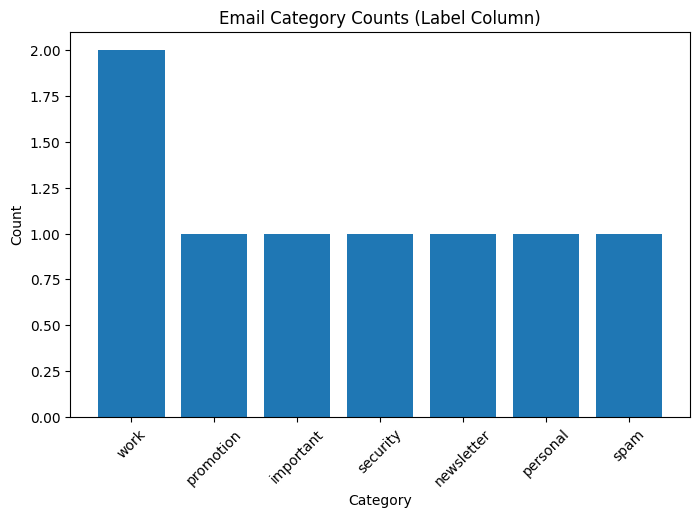

In [20]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(label_counts.index, label_counts.values)
plt.xticks(rotation=45)
plt.title("Email Category Counts (Label Column)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

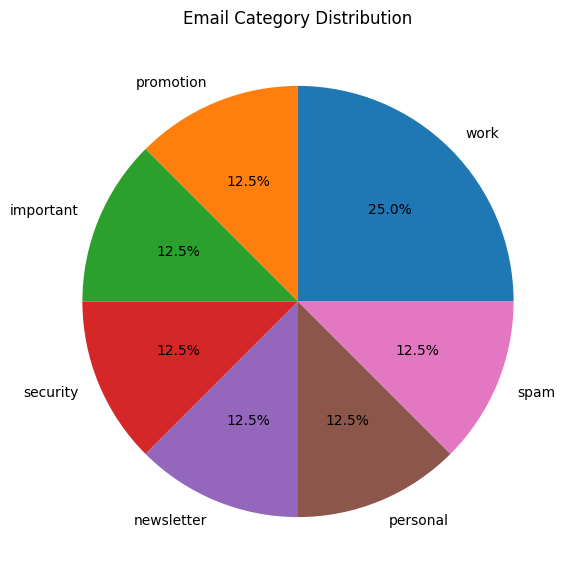

In [21]:
plt.figure(figsize=(7,7))
plt.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%')
plt.title("Email Category Distribution")
plt.show()